In [1]:
from utils.clustering_preprocessing_utils import ClusteringPreprocessor
preprocessor = ClusteringPreprocessor(sensors_path="../../../../../data/ml/features.csv", target_path="../../../../../data/ml/targets.csv")

In [2]:
sensor_df, target_df = preprocessor.read_data()
preprocessor.feature_selection()
preprocessor.normalize_column(column_name="Angle[degree]ORDistance[mm]")

,Unnamed: 0,Experiment_ID,Angle[degree]ORDistance[mm],Secondary-axis [mm],Main-axis [mm],Out-of-roundness [-],Collapse [mm]
0,0,2,0.000000,0.317461,0.337050,0.626034,0.344543
1,1,2,0.022036,0.319825,0.363018,0.600159,0.372211
2,2,2,0.044072,0.319035,0.401244,0.560835,0.412939
3,3,2,0.066108,0.317768,0.438220,0.522651,0.452336
4,4,2,0.088145,0.320230,0.465094,0.495879,0.480970
...,...,...,...,...,...,...,...
4616,14374,314,0.903482,0.602647,0.400094,0.641878,0.341981
4617,14375,314,0.925518,0.618405,0.398324,0.648210,0.340095
4618,14376,314,0.947554,0.631936,0.397945,0.652486,0.339691
4619,14377,314,0.969590,0.640013,0.399376,0.653355,0.341216


In [3]:
X = preprocessor.group_and_pad(preprocessor.sensor_df, group_col="Experiment_ID")[:,:,:]
Y = preprocessor.group_and_pad(preprocessor.target_df, group_col="Experiment_ID")[:,:,1:-1]
X.shape, Y.shape

((100, 1743, 17), (100, 47, 4))

In [4]:
from utils.clustering_utils import KMeansClusterer, KSelectionEvaluator

/home/arman/Documents/univrsity/Master/Master these 2025/tube-geometry-prediction/tube-venv/lib/python3.11/site-packages/tslearn/bases/bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


In [5]:
experiment_ids = list(sensor_df.Experiment_ID.unique().astype(int))
experiment_ids = [int(x) for x in experiment_ids]
experiment_ids

[2,
 4,
 6,
 8,
 10,
 12,
 14,
 16,
 18,
 20,
 22,
 24,
 26,
 28,
 30,
 32,
 34,
 36,
 38,
 39,
 40,
 41,
 42,
 49,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 119,
 124,
 190,
 193,
 196,
 199,
 202,
 205,
 208,
 211,
 214,
 217,
 220,
 223,
 226,
 229,
 232,
 235,
 238,
 241,
 244,
 245,
 246,
 253,
 254,
 255,
 262,
 265,
 268,
 271,
 274,
 277,
 280,
 285,
 290,
 293,
 296,
 299,
 302,
 305,
 308,
 311,
 314]

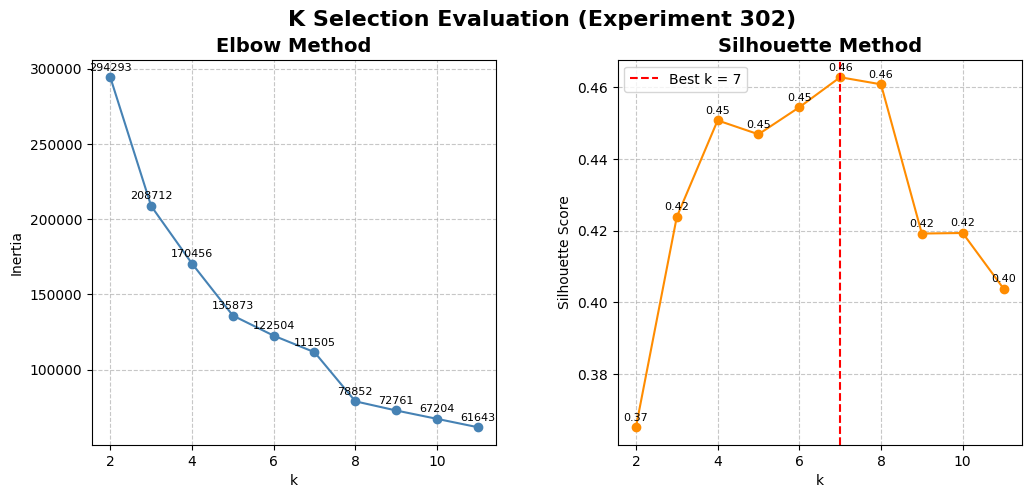

In [6]:
k_selection = KSelectionEvaluator(X, random_state=42, experiment_ids=experiment_ids)
inertias, silhouettes, best_k = k_selection.evaluate(experiment_id=302, window_size=15)

In [7]:
feature_names= list(sensor_df.columns)
feature_names.remove("Experiment_ID")

# "kmeans", "agglo", "dbscan", "kshape", "tskm"

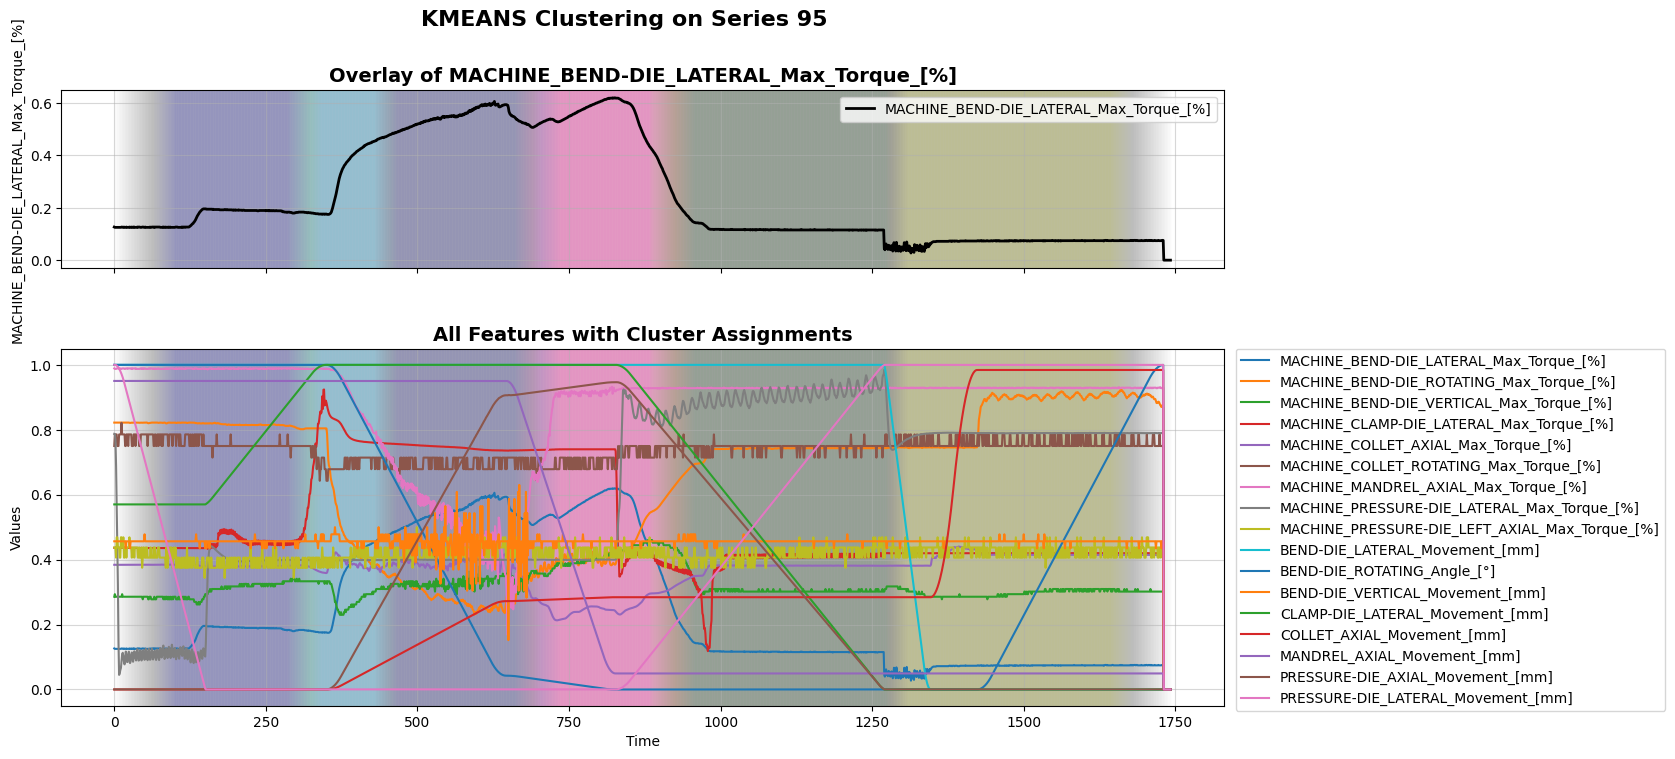

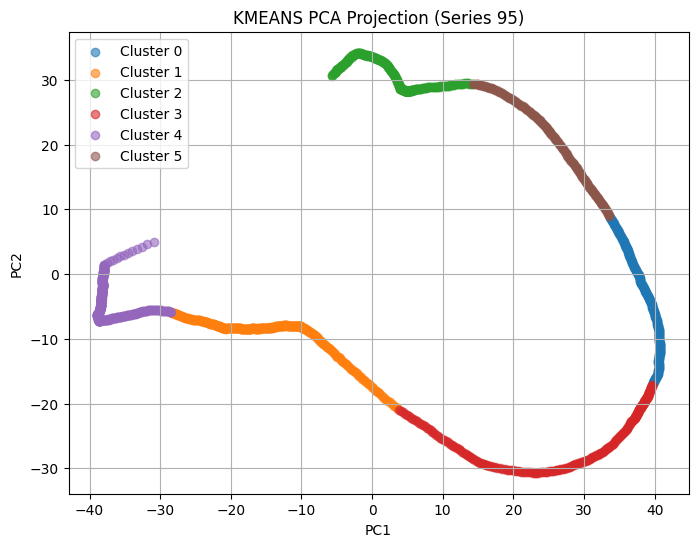

In [14]:
kmeans_clusterer = KMeansClusterer(X, random_state=42, experiment_ids=experiment_ids)
labels, kmeans, subsequences_pca = kmeans_clusterer.cluster(
    experiment_id=302, window_size=100, n_clusters=6,feature_names=feature_names, algorithm= "kmeans"
)